LSTM — MIT-BIH ECG Time-Series

CELL 1 — Install & Import Libraries

In [1]:
# Run this once in terminal if not installed:
# pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score)
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow Version: 2.21.0
All libraries loaded ✅


CELL 2 — Load Dataset 

In [2]:
# Place mitbih_train.csv and mitbih_test.csv in same folder as this notebook

train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df  = pd.read_csv("mitbih_test.csv",  header=None)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("✅ Dataset loaded successfully!")

Train shape: (87554, 188)
Test  shape: (21892, 188)
✅ Dataset loaded successfully!


 CELL 3 — Explore Data

=== Class Distribution (Train) ===
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


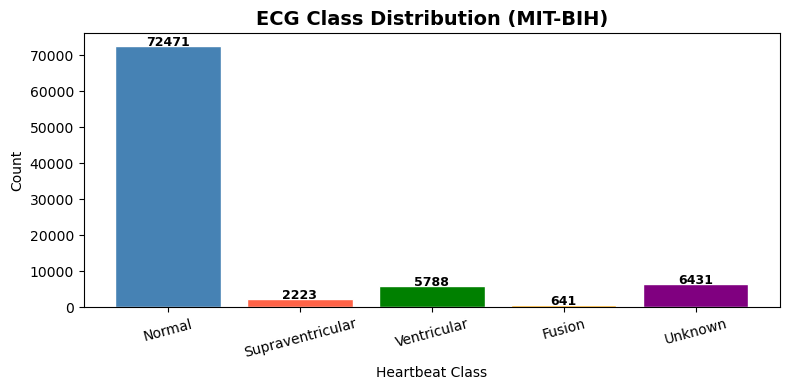

In [3]:
# Class names
class_names = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown'
}

print("=== Class Distribution (Train) ===")
print(train_df[187].value_counts().sort_index())

# Plot class distribution
plt.figure(figsize=(8, 4))
counts = train_df[187].value_counts().sort_index()
bars = plt.bar(
    [class_names[i] for i in counts.index],
    counts.values,
    color=['steelblue','tomato','green','orange','purple'],
    edgecolor='white'
)
plt.title('ECG Class Distribution (MIT-BIH)', fontsize=14, fontweight='bold')
plt.xlabel('Heartbeat Class')
plt.ylabel('Count')
plt.xticks(rotation=15)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(val), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_class_distribution.png', dpi=150)
plt.show()

CELL 4 — Visualize Sample ECG Signals

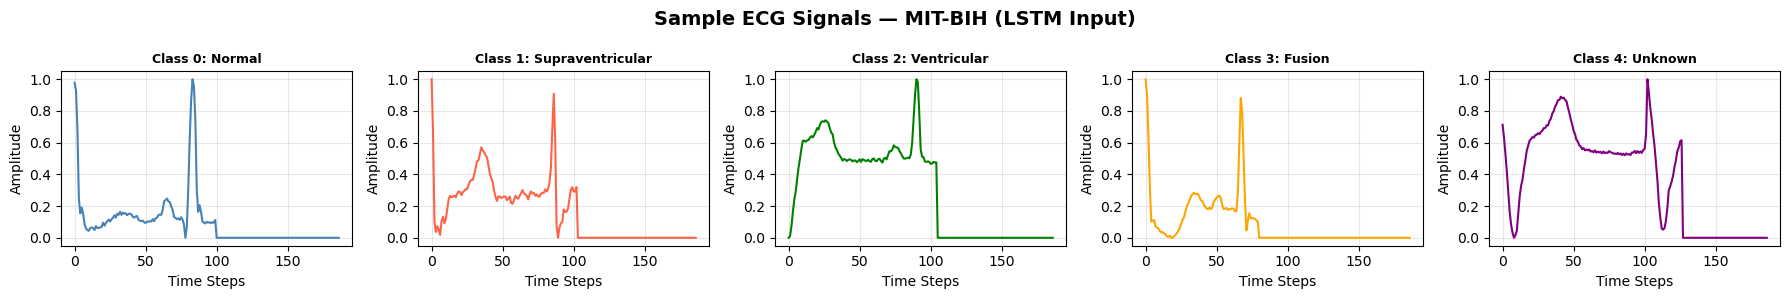

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['steelblue','tomato','green','orange','purple']

for i in range(5):
    sample = train_df[train_df[187] == i].iloc[0, :187].values
    axes[i].plot(sample, color=colors[i], linewidth=1.5)
    axes[i].set_title(f'Class {i}: {class_names[i]}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sample ECG Signals — MIT-BIH (LSTM Input)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_sample_signals.png', dpi=150)
plt.show()

CELL 5 — Preprocessing & Balancing

In [8]:
from collections import Counter

# Split features and labels
X_train = train_df.iloc[:, :187].values
y_train = train_df[187].values.astype(int)

X_test  = test_df.iloc[:, :187].values
y_test  = test_df[187].values.astype(int)

print("Before balancing:", Counter(y_train))

# ✅ FIX: Use only 3000 samples per class instead of full majority count
SAMPLES_PER_CLASS = 3000   # ← This is the key change

df_train_bal = pd.DataFrame(X_train)
df_train_bal['label'] = y_train

balanced_dfs = []
for cls in range(5):
    cls_df = df_train_bal[df_train_bal['label'] == cls]
    cls_resampled = resample(
        cls_df,
        replace=True,
        n_samples=SAMPLES_PER_CLASS,
        random_state=42
    )
    balanced_dfs.append(cls_resampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42)

X_train = df_balanced.iloc[:, :187].values
y_train = df_balanced['label'].values.astype(int)

print("After balancing :", Counter(y_train))
print("Total samples   :", len(X_train))  # Should be 15000

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], 187, 1)
X_test  = X_test.reshape(X_test.shape[0],  187, 1)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)

print("\nX_train shape:", X_train.shape)
print("✅ Preprocessing complete!")

Before balancing: Counter({np.int64(0): 72471, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
After balancing : Counter({np.int64(3): 3000, np.int64(2): 3000, np.int64(4): 3000, np.int64(0): 3000, np.int64(1): 3000})
Total samples   : 15000

X_train shape: (15000, 187, 1)
✅ Preprocessing complete!


CELL 6 — Build LSTM Model


In [9]:
# ✅ FIX: Removed Bidirectional, reduced units — much faster on CPU

model = Sequential([

    # LSTM Layer 1
    LSTM(64, return_sequences=True, input_shape=(187, 1)),
    BatchNormalization(),
    Dropout(0.3),

    # LSTM Layer 2
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Dense Layers
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ABHINAV\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 187, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,917 (120.77 KB)

 Trainable params: 30,725 (120.02 KB)

 Non-trainable params: 192 (768.00 B)

CELL 7 — Train the Model

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                  # ✅ Reduced from 8
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,                  # ✅ Reduced from 4
    min_lr=1e-6,
    verbose=1
)

print("🚀 Starting LSTM Training (Fast Version)...")
history = model.fit(
    X_train, y_train_cat,
    epochs=20,                   # ✅ Reduced from 50
    batch_size=128,              # ✅ Increased from 64 — faster per epoch
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ LSTM Training Complete!")

🚀 Starting LSTM Training (Fast Version)...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.2230 - loss: 1.6602 - val_accuracy: 0.2180 - val_loss: 1.6136 - learning_rate: 0.0010
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.3243 - loss: 1.5007 - val_accuracy: 0.1947 - val_loss: 1.6270 - learning_rate: 0.0010
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 194ms/step - accuracy: 0.4101 - loss: 1.3737 - val_accuracy: 0.1960 - val_loss: 1.6302 - learning_rate: 0.0010
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.4382 - loss: 1.3219 - val_accuracy: 0.2080 - val_loss: 1.4771 - learning_rate: 0.0010
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.4853 - loss: 1.2522 - val_accuracy: 0.3473 - val_loss: 1.3560 - learning_rate: 0.0010
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.5271 - loss: 1.1706 - val_accuracy: 0.3327 - val_loss: 1.6156 - learning_rate: 0.0010
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1

CELL 8 — Accuracy & Loss Graphs


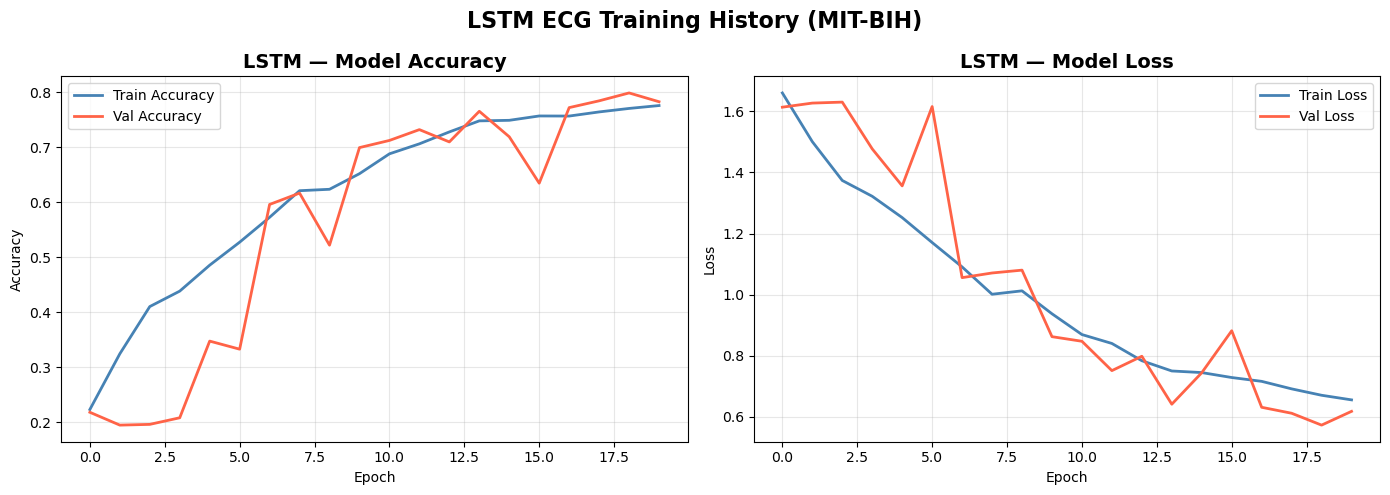

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy',   color='tomato',    linewidth=2)
axes[0].set_title('LSTM — Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val Loss',   color='tomato',    linewidth=2)
axes[1].set_title('LSTM — Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM ECG Training History (MIT-BIH)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

CELL 9 — Evaluate Model

In [12]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ LSTM Test Accuracy: {acc*100:.2f}%")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=list(class_names.values())
))

685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
✅ LSTM Test Accuracy: 81.11%

=== Classification Report ===
                  precision    recall  f1-score   support

          Normal       0.97      0.82      0.89     18118
Supraventricular       0.22      0.63      0.32       556
     Ventricular       0.54      0.71      0.61      1448
          Fusion       0.10      0.82      0.17       162
         Unknown       0.81      0.87      0.84      1608

        accuracy                           0.81     21892
       macro avg       0.53      0.77      0.57     21892
    weighted avg       0.91      0.81      0.85     21892



CELL 10 — Confusion Matrix

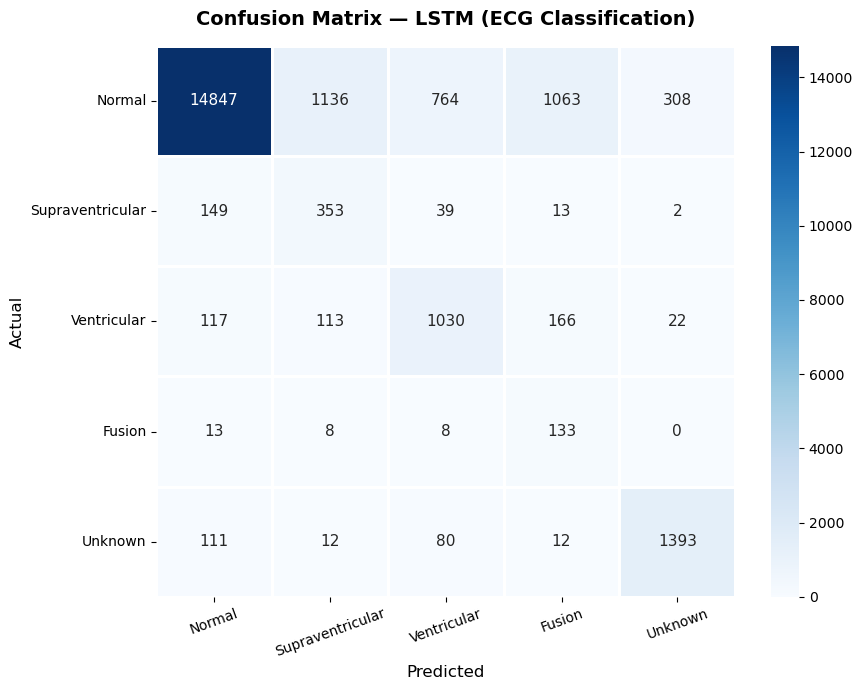

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(class_names.values()),
            yticklabels=list(class_names.values()),
            linewidths=0.8, linecolor='white',
            annot_kws={"size": 11})

plt.title('Confusion Matrix — LSTM (ECG Classification)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual',    fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

CELL 11 — Per-Class Accuracy Bar Chart

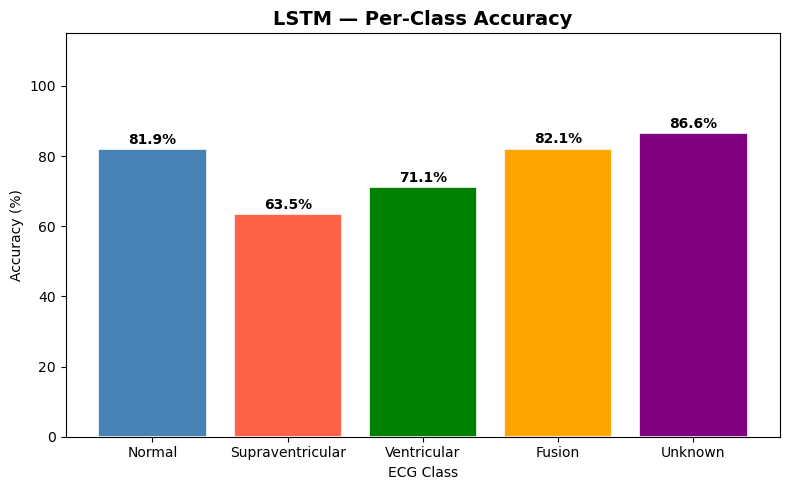

In [14]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    list(class_names.values()),
    per_class_acc * 100,
    color=['steelblue','tomato','green','orange','purple'],
    edgecolor='white', linewidth=1.2
)
plt.title('LSTM — Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('ECG Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{val*100:.1f}%',
             ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('lstm_per_class_accuracy.png', dpi=150)
plt.show()

CELL 12 — Compare LSTM vs CNN1D

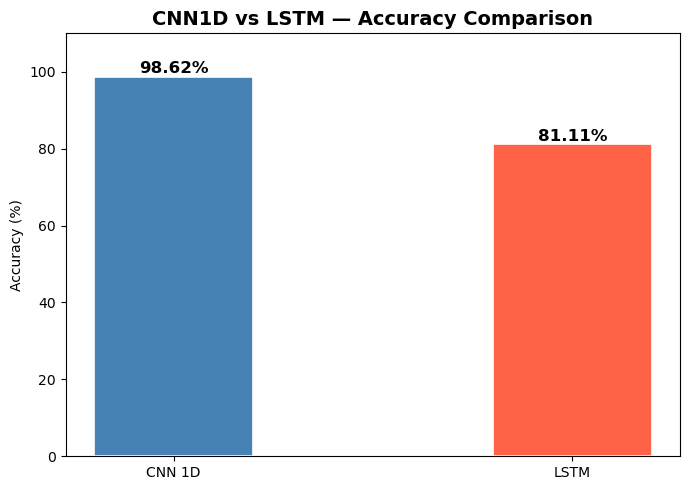

In [ ]:
# Add your CNN1D accuracy here from previous notebook
cnn1d_acc = 98.62   
lstm_acc  = acc * 100

models      = ['CNN 1D', 'LSTM']
accuracies  = [cnn1d_acc, lstm_acc]
colors      = ['steelblue', 'tomato']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors,
               edgecolor='white', linewidth=1.2, width=0.4)
plt.title('CNN1D vs LSTM — Accuracy Comparison',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.2f}%',
             ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_vs_cnn1d_comparison.png', dpi=150)
plt.show()

CELL 13 — Save Model

In [16]:
model.save('lstm_ecg_model.h5')
print("✅ LSTM model saved as lstm_ecg_model.h5")
print("\n📁 Files saved in your project folder:")
print("   - lstm_accuracy_loss.png")
print("   - lstm_confusion_matrix.png")
print("   - lstm_per_class_accuracy.png")
print("   - lstm_vs_cnn1d_comparison.png")
print("   - lstm_sample_signals.png")
print("   - lstm_ecg_model.h5")

✅ LSTM model saved as lstm_ecg_model.h5

📁 Files saved in your project folder:
   - lstm_accuracy_loss.png
   - lstm_confusion_matrix.png
   - lstm_per_class_accuracy.png
   - lstm_vs_cnn1d_comparison.png
   - lstm_sample_signals.png
   - lstm_ecg_model.h5
